### Today task is to compare the performance of:
	•	A CNN trained from scratch
	•	A model using Transfer Learning (MobileNetV2)

for classifying flower images.



#### After this lab, students will be able to:
	•	Build a CNN model from scratch
	•	Apply transfer learning using a pre-trained network
	•	Compare training accuracy, Precision and Recall
	•	Analyze learning curves
	•	Understand why transfer learning is effective

#### 🧑‍🎓 Student Details

| Field                | Information                |
|---------------------|----------------------------|
| 👨‍🎓 **Name**            | [Dhanush D]     |
| 🆔 **USN**              | _[1RUA24CSE0122]_           |
| **Section**        | _[G]_ |
| **Programme**   | B.Tech(H)             |
| **School**  | Computer Science and Engineering |


### Transfer Learning reuses knowledge learned from large datasets (e.g., ImageNet) to solve new problems efficiently.

#### Key idea:
	•	Early CNN layers learn generic features (edges, textures)
	•	Later layers learn task-specific features
	•	We reuse earlier layers and train only new layers


In [1]:
!pip install opencv-python


**Task 01:** Load the important libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import cv2
print(cv2.__version__)

#Write your code below this line

4.13.0


**Task 02:** Load Dataset

We use the TensorFlow Flower dataset containing 5 classes.

In [3]:
!pip install keras


In [4]:
import tensorflow as tf
from tensorflow import keras
import pathlib

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = keras.utils.get_file("flower_photos", origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir)

print("data_dir =", data_dir)


data_dir = C:\Users\dhanu\.keras\datasets\flower_photos


**Task 03:** Data Exploration

In [5]:
if (data_dir / "flower_photos").exists():
    data_dir = data_dir / "flower_photos"
    print("Fixed data_dir =", data_dir)

Fixed data_dir = C:\Users\dhanu\.keras\datasets\flower_photos\flower_photos


In [6]:
print("Total jpg:", len(list(data_dir.glob("*/*.jpg"))))
print("Class counts:")
for cls in ["roses","daisy","dandelion","sunflowers","tulips"]:
    print(cls, len(list(data_dir.glob(f"{cls}/*.jpg"))))

Total jpg: 3670
Class counts:
roses 641
daisy 633
dandelion 898
sunflowers 699
tulips 799


In [7]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

**Task 04:** — Create Training and Validation Sets

In [8]:
IMG_SIZE = (224,224)      # Fill
BATCH_SIZE = 32          # Fill
SEED = 123

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.25,
    subset = "training",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.25,
    subset = "validation",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

Found 3670 files belonging to 5 classes.
Using 2753 files for training.
Found 3670 files belonging to 5 classes.
Using 917 files for validation.
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


**Task 05:** Visualizing Simple Images for Pre-check

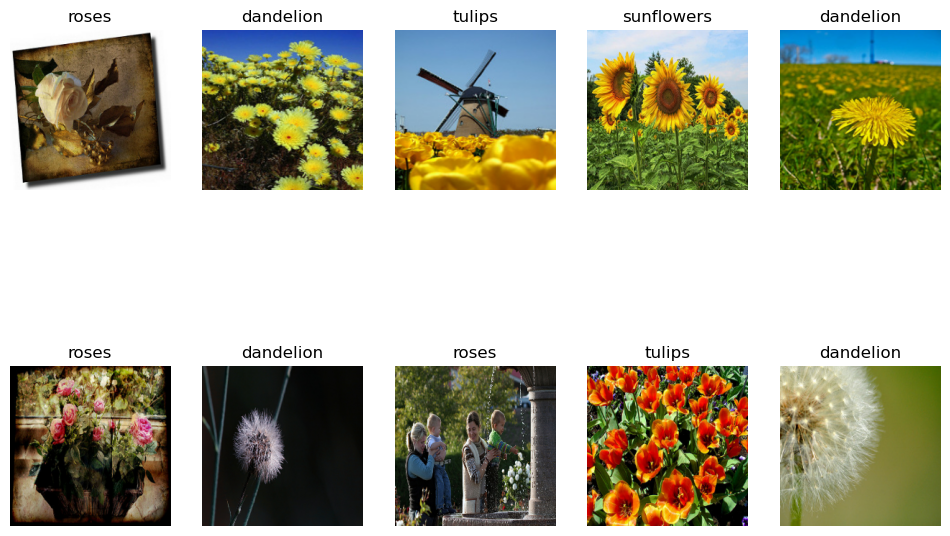

In [9]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[int(labels[i])])
    plt.axis("off")
plt.show()

**Task 06:** — Optimize Dataset Pipeline

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

normalizer = layers.Rescaling(1./255)

**Task 07** -- Implement CNN without Transfer Learning

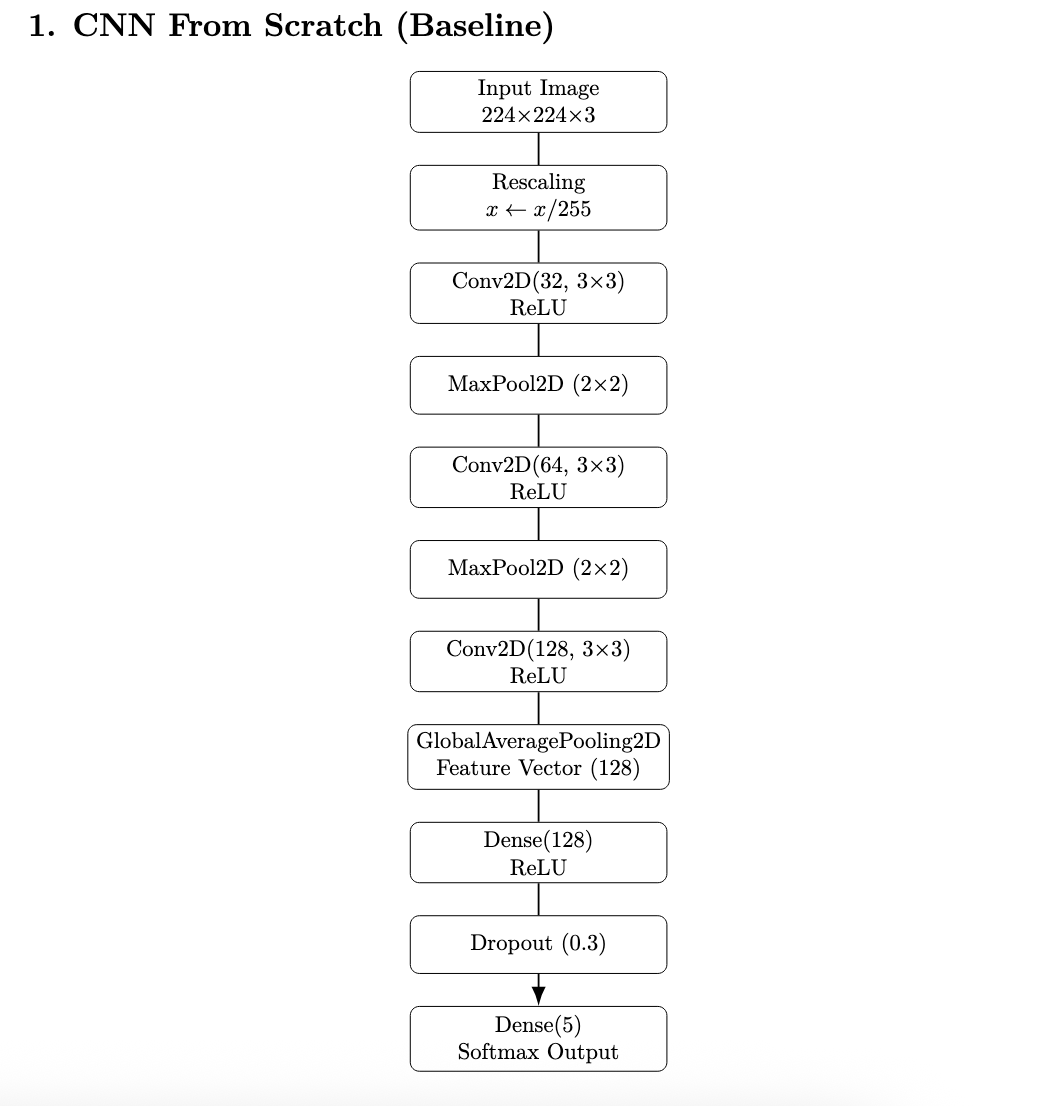

In [11]:
baseline_model = keras.Sequential([

    layers.Input(shape = IMG_SIZE + (3,)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

**Task 08:** Train the baseline model for study

In [12]:
history_baseline = baseline_model.fit(
    train_ds, 
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.3476 - loss: 1.4228 - val_accuracy: 0.4253 - val_loss: 1.2979
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.4366 - loss: 1.2444 - val_accuracy: 0.4755 - val_loss: 1.2314
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.4664 - loss: 1.2097 - val_accuracy: 0.5267 - val_loss: 1.1760
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.5162 - loss: 1.1472 - val_accuracy: 0.5474 - val_loss: 1.1226
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.5278 - loss: 1.1201 - val_accuracy: 0.5431 - val_loss: 1.1325
Epoch 6/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.5579 - loss: 1.0806 - val_accuracy: 0.5889 - val_loss: 1.0494
Epoch 7/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.5786 - loss: 1.0566 - val_accuracy: 0.5605 - val_loss: 1.0996
Epoch 8/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.6077 - loss: 1.0087 - val_accuracy: 0.5823 - v

Task 09: Implement the CNN with Transfer Learning using MobileVnet Model [ Lightweight ]

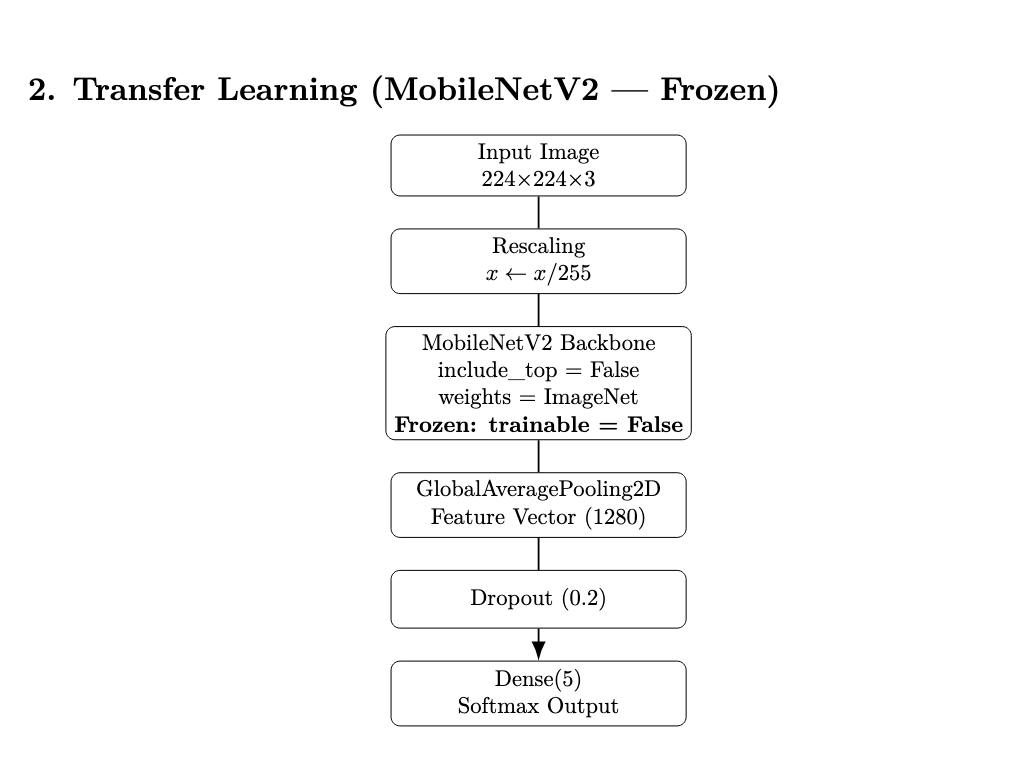

In [13]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape = IMG_SIZE + (3,),
    include_top = False,    # Fill
    weights =   "imagenet"   # Fill
)

base_model.trainable = False  # Freeze or not?

tl_model = keras.Sequential([
    layers.Input(shape = IMG_SIZE + (3,)),
    normalizer,
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),   # Fill
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation="softmax")
])

In [14]:
tl_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tl_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_2 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │           6,405 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Task 10:** Train the tranfer learning model

In [15]:
history_tl = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.1994 - loss: 1.7334 - val_accuracy: 0.2126 - val_loss: 1.6558
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.2121 - loss: 1.6921 - val_accuracy: 0.2061 - val_loss: 1.6209
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.2165 - loss: 1.7001 - val_accuracy: 0.1734 - val_loss: 1.6774
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.2147 - loss: 1.6869 - val_accuracy: 0.3064 - val_loss: 1.5993
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 81s 933ms/step - accuracy: 0.2223 - loss: 1.6761 - val_accuracy: 0.2388 - val_loss: 1.6396
Epoch 6/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 86s 993ms/step - accuracy: 0.2314 - loss: 1.6721 - val_accuracy: 0.1734 - val_loss: 1.6066
Epoch 7/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.2307 - loss: 1.6640 - val_accuracy: 0.3010 - val_loss: 1.5924
Epoch 8/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 84s 962ms/step - accuracy: 0.2343 - loss: 1.6536 - val_accuracy: 0.2803

#Compare the Learning curves of both

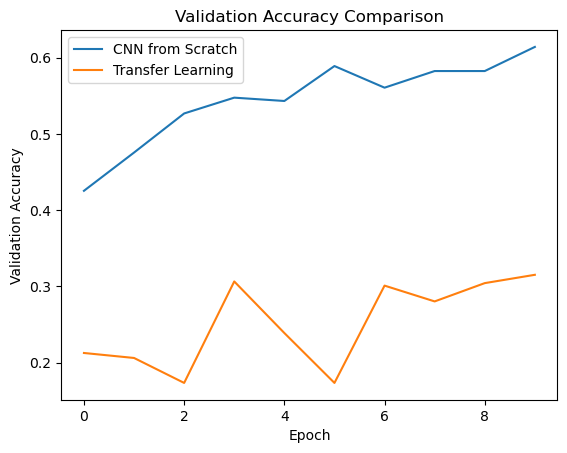

In [16]:
plt.figure()

plt.plot(history_baseline.history["val_accuracy"],
         label="CNN from Scratch")

plt.plot(history_tl.history["val_accuracy"],
         label="Transfer Learning")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.show()

### Performance Comparison Table

In [17]:
import pandas as pd

summary = pd.DataFrame([
    {
        "Model": "CNN from Scratch",
        "Epochs": len(history_baseline.history["val_accuracy"]),
        "Total Params": baseline_model.count_params(),
        "Best Val Acc": max(history_baseline.history["val_accuracy"])
    },
    {
        "Model": "Transfer Learning",
        "Epochs": len(history_tl.history["val_accuracy"]),
        "Total Params": tl_model.count_params(),
        "Best Val Acc": max(history_tl.history["val_accuracy"])
    }
])

summary

,Model,Epochs,Total Params,Best Val Acc
0,CNN from Scratch,10,110405,0.613959
1,Transfer Learning,10,2264389,0.315158


## Answer the following questions:

1. Which model converges faster?
2. Which model shows higher validation accuracy?
3. Does CNN from scratch show signs of overfitting? Explain.
4. Why does TL have many parameters but few trainable ones?
5. Why does freezing layers reduce training time?
6. Which model requires more data to train effectively?

## Prediction on Validation Data

In [ ]:
import numpy as np

def get_true_and_pred(model, dataset):
    y_true = []
    y_pred = []

    for x_batch, y_batch in dataset:
        probs = model.predict(x_batch, verbose=0)     # (batch, num_classes)
        preds = np.argmax(probs, axis=1)             # predicted class index

        y_true.extend(y_batch.numpy())
        y_pred.extend(preds)

    return np.array(y_true), np.array(y_pred)

y_true_base, y_pred_base = get_true_and_pred(baseline_model, val_ds)
y_true_tl,   y_pred_tl   = get_true_and_pred(tl_model, val_ds)

In [19]:
acc_base = (y_true_base == y_pred_base).mean()
acc_tl   = (y_true_tl == y_pred_tl).mean()

print("Baseline CNN Test Accuracy:", round(acc_base, 4))
print("Transfer Learning Test Accuracy:", round(acc_tl, 4))

Baseline CNN Test Accuracy: 0.614
Transfer Learning Test Accuracy: 0.3152


<Figure size 640x480 with 0 Axes>

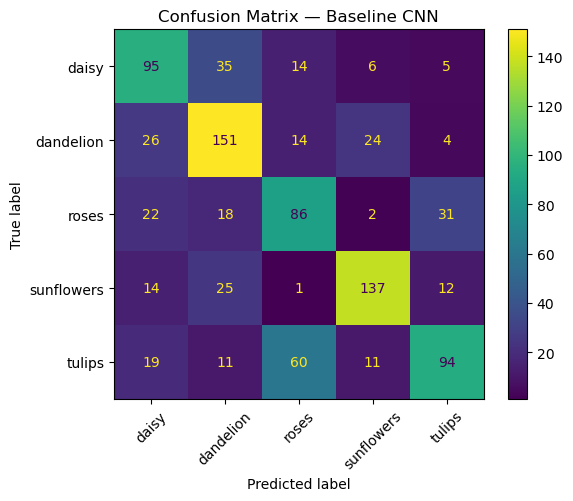

<Figure size 640x480 with 0 Axes>

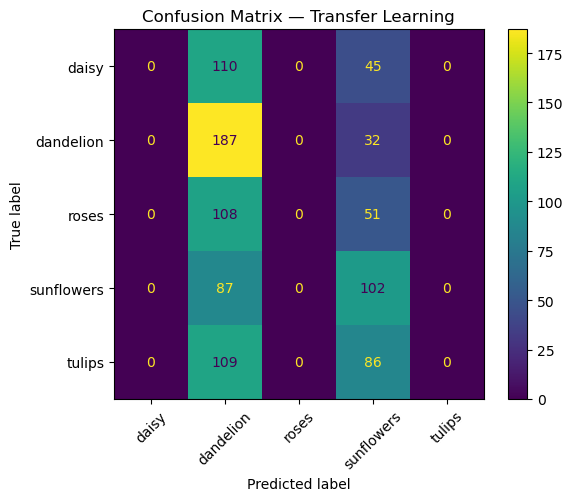

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_base = confusion_matrix(y_true_base, y_pred_base)
cm_tl   = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure()
ConfusionMatrixDisplay(cm_base, display_labels=class_names).plot(xticks_rotation=45)
plt.title("Confusion Matrix — Baseline CNN")
plt.show()

plt.figure()
ConfusionMatrixDisplay(cm_tl, display_labels=class_names).plot(xticks_rotation=45)
plt.title("Confusion Matrix — Transfer Learning")
plt.show()

## Answer the following questions:

1. Which classes are most confused by CNN from scratch?
2. Which class shows highest accuracy in TL model?
3. Why might “roses” be harder to classify than “sunflowers”?

In [21]:
from sklearn.metrics import classification_report

print("=== Baseline CNN Report ===")
print(classification_report(y_true_base, y_pred_base, target_names=class_names))

print("=== Transfer Learning Report ===")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

=== Baseline CNN Report ===
              precision    recall  f1-score   support

       daisy       0.54      0.61      0.57       155
   dandelion       0.63      0.69      0.66       219
       roses       0.49      0.54      0.51       159
  sunflowers       0.76      0.72      0.74       189
      tulips       0.64      0.48      0.55       195

    accuracy                           0.61       917
   macro avg       0.61      0.61      0.61       917
weighted avg       0.62      0.61      0.61       917

=== Transfer Learning Report ===
              precision    recall  f1-score   support

       daisy       0.00      0.00      0.00       155
   dandelion       0.31      0.85      0.46       219
       roses       0.00      0.00      0.00       159
  sunflowers       0.32      0.54      0.40       189
      tulips       0.00      0.00      0.00       195

    accuracy                           0.32       917
   macro avg       0.13      0.28      0.17       917
weighted avg    

C:\Users\dhanu\miniconda3\envs\datascience_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dhanu\miniconda3\envs\datascience_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dhanu\miniconda3\envs\datascience_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

## Answer the following questions:

1.	Which class has lowest F1-score in baseline CNN?
2.	How much did overall accuracy improve using TL?
3.	Why does precision differ from recall?

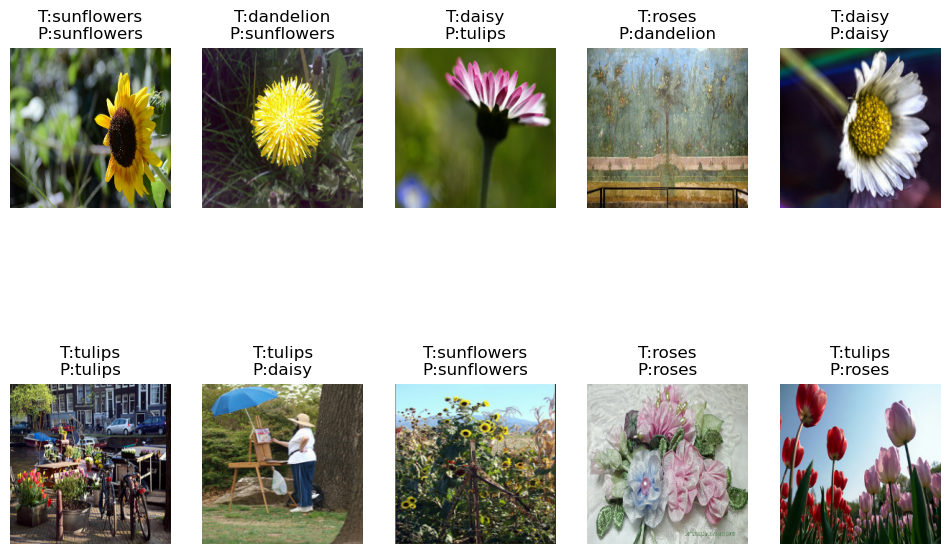

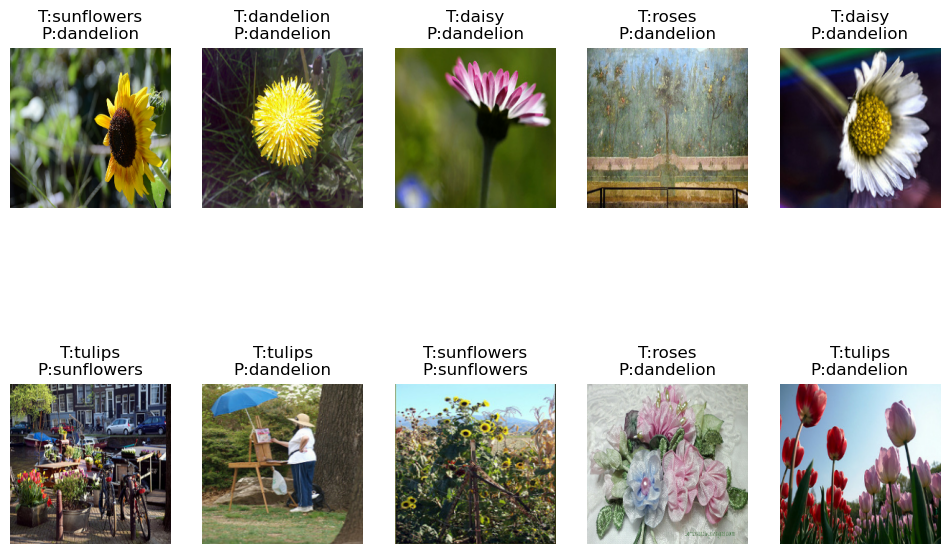

In [22]:
import matplotlib.pyplot as plt

def show_prediction_grid(model, dataset, class_names, n=10):
    images, labels = next(iter(dataset))
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    plt.figure(figsize=(12,8))
    for i in range(n):
        ax = plt.subplot(2, 5, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        t = class_names[int(labels[i])]
        p = class_names[int(preds[i])]
        plt.title(f"T:{t}\nP:{p}")
        plt.axis("off")
    plt.show()

show_prediction_grid(baseline_model, val_ds, class_names, n=10)
show_prediction_grid(tl_model, val_ds, class_names, n=10)

Questions:

	1.	Why does TL have many parameters but few trainable ones?
	2.	Why does freezing layers reduce training time?
	3.	Which model requires more data to train effectively?

## Test on new data

In [24]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

IMG_SIZE = (224, 224)

def preprocess_image(image_path):
    img = load_img(image_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    return img_array

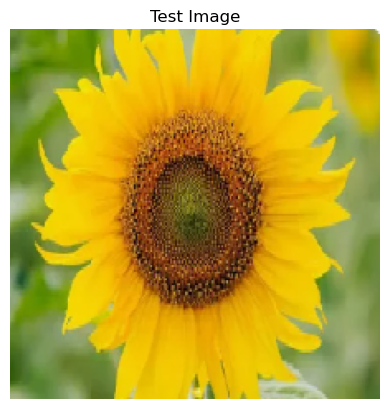

In [27]:
import matplotlib.pyplot as plt

img = load_img("image.png", target_size=IMG_SIZE)

plt.imshow(img)
plt.axis("off")
plt.title("Test Image")
plt.show()

In [28]:
test_image = preprocess_image("image.png")

predictions = tl_model.predict(test_image)

predicted_class = np.argmax(predictions[0])
confidence = np.max(predictions[0])

print("Predicted Flower:", class_names[predicted_class])
print("Confidence:", round(confidence*100, 2), "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
Predicted Flower: dandelion
Confidence: 32.41 %


**Final Task for Students:** Fine-Tuning Task - Unfreeze last layers of MobileNetV2 and retrain for 3 epochs.

Interpret:

	•	Accuracy change
	•	Overfitting risk

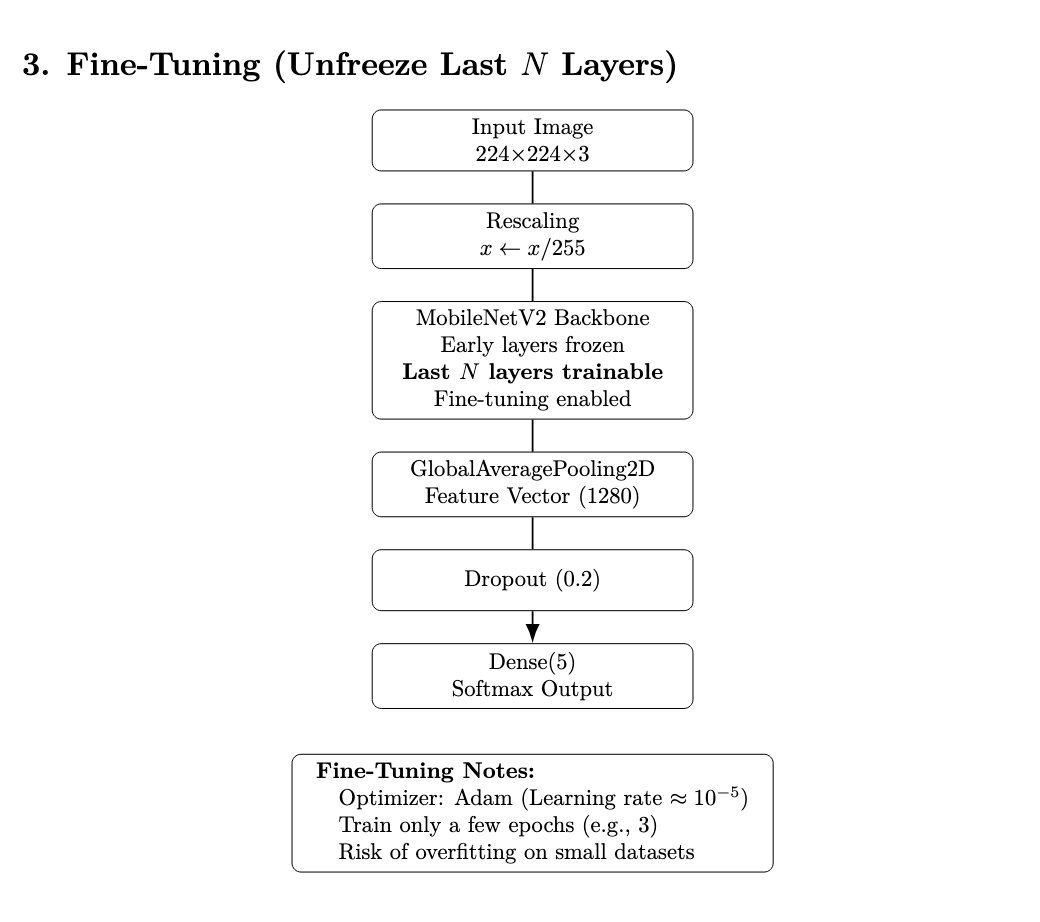

In [31]:

from tensorflow.keras import layers, models, optimizers

base_model = tf.keras.applications.MobileNetV2(
    input_shape = IMG_SIZE + (3,),
    include_top = False,
    weights = "imagenet"
)

base_model.trainable = True

fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

fine_tune = models.Sequential([
    layers.Input(shape = IMG_SIZE + (3,)),
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(5, activation="softmax")
])

fine_tune.compile(
    optimizer = optimizers.Adam(learning_rate=1e-5), 
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [ ]:
history_ft=fine_tune.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
50/87 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.2520 - loss: 1.8864 

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_baseline.history["val_accuracy"],
         label="CNN from Scratch")

plt.plot(history_tl.history["val_accuracy"],
         label="Transfer Learning")

plt.plot(history_ft.history["val_accuracy"],
         label="Fine Tuned MobileNetV2")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_baseline.history["accuracy"], label="Baseline Train")
plt.plot(history_tl.history["accuracy"], label="TL Train")
plt.plot(history_ft.history["accuracy"], label="Fine Tune Train")

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()